# 01. Подготовка данных
Генерация синтетического экономического ряда, детрендирование, Z-нормализация (статистики только по train), хронологический сплит и формирование скользящих окон.

In [2]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd() / "notebooks").exists() is False and pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
# делаем import tsprep рабочим независимо от того, откуда запущен ноутбук
for cand in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    src = cand / "src"
    if src.exists():
        sys.path.insert(0, str(src))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(42)


## 1.1 Синтетический ряд
Стохастический тренд + многомасштабная сезонность + GARCH-подобная волатильность + структурные сдвиги режимов + внесённые точечные аномалии.

values: (4000, 1) regimes: [0 1 2] anomalies: 41


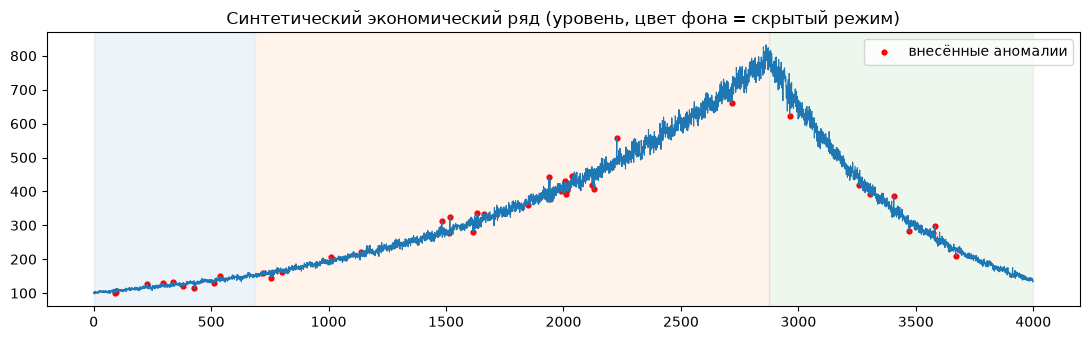

In [3]:
from tsprep.data_preprocessing.synthetic import generate_series

series = generate_series(length=4000, n_features=1, n_regimes=3, anomaly_rate=0.01, seed=42)
print("values:", series.values.shape, "regimes:", np.unique(series.regime), "anomalies:", series.is_anomaly.sum())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(series.values[:, 0], lw=0.8)
for r in np.unique(series.regime):
    idx = np.where(series.regime == r)[0]
    ax.axvspan(idx.min(), idx.max(), alpha=0.08, color=f"C{r}")
ax.scatter(np.where(series.is_anomaly)[0], series.values[series.is_anomaly, 0], color="red", s=12, label="внесённые аномалии")
ax.set_title("Синтетический экономический ряд (уровень, цвет фона = скрытый режим)")
ax.legend()
fig.tight_layout()


## 1.2 Детрендирование и нормализация
Обычная первая разность, статистики Z-нормализации считаются **только по train-диапазону**, чтобы не допустить утечки данных из будущего.

<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
C:\Users\PC\AppData\Local\Temp\ipykernel_26256\414928224.py:10: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_title("Первая разность $\Delta$y_t (до нормализации)")


delta shape: (3999, 1) | n_train: 2799
train mean/std: [0.23138483] [13.32735488]


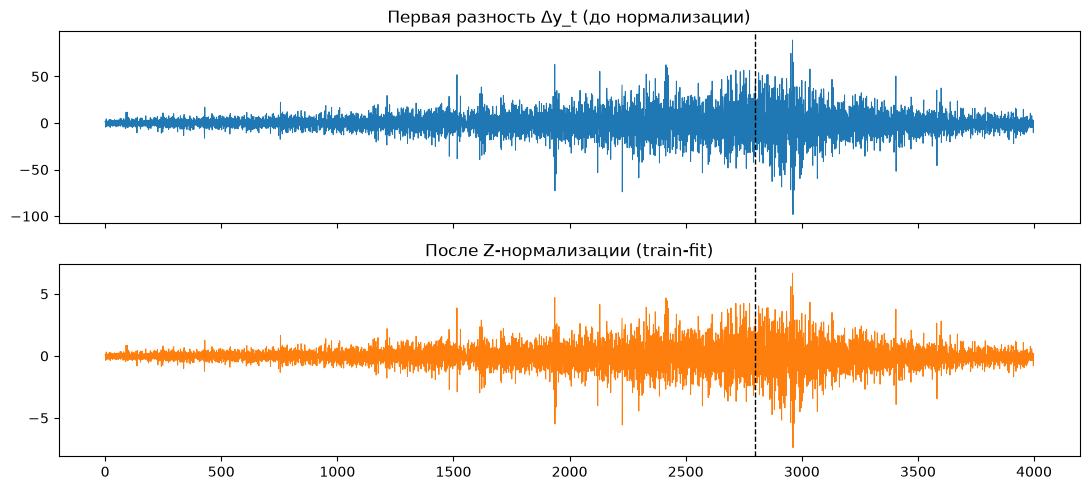

In [7]:
from tsprep.data_preprocessing.preprocessing import prepare_series

prep = prepare_series(series.values, seasonal_period=1, train_frac=0.70)
print("delta shape:", prep["delta"].shape, "| n_train:", prep["n_train"])
print("train mean/std:", prep["normalizer"].mean_, prep["normalizer"].std_)

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(prep["delta"][:, 0], lw=0.7)
axes[0].axvline(prep["n_train"], color="k", ls="--", lw=1)
axes[0].set_title("Первая разность $\Delta$y_t (до нормализации)")
axes[1].plot(prep["normalized"][:, 0], lw=0.7, color="C1")
axes[1].axvline(prep["n_train"], color="k", ls="--", lw=1)
axes[1].set_title("После Z-нормализации (train-fit)")
fig.tight_layout()


## 1.3 Хронологический сплит + скользящее окно
70/15/15 по времени (без перемешивания), затем окна `X^(i) = [x'_i, ..., x'_{i+T-1}]` строятся отдельно на каждом под-диапазоне.

In [5]:
from tsprep.config import DataConfig
from tsprep.data_preprocessing.datasets import prepare_and_window, build_dataloaders

data_cfg = DataConfig(window_len=64, stride=1, n_features=1, batch_size=64)
prepared = prepare_and_window(series.values, data_cfg, regime=series.regime, is_anomaly=series.is_anomaly)

print("train windows:", prepared.train_windows.shape)
print("val   windows:", prepared.val_windows.shape)
print("test  windows:", prepared.test_windows.shape)

train_loader, val_loader, test_loader = build_dataloaders(prepared, data_cfg)
batch = next(iter(train_loader))
print("batch shape:", batch.shape, "(B, T, F)")


train windows: (2736, 64, 1)
val   windows: (536, 64, 1)
test  windows: (538, 64, 1)
batch shape: torch.Size([64, 64, 1]) (B, T, F)
